# 08 – Keystroke-aware reranking (postprocessing stage 6)

Short frequent words (*the, and, a, I*) are the most probable next words but save almost no keystrokes when tapped. **Stage 6** of `src/postprocess.py` orders the candidates by the *expected number of keystrokes saved* instead of by probability alone:

> score(w) = P(w) × (len(w) − len(typed prefix))

(`P(w)` is the model probability, renormalised over the words that match the typed prefix; the ordering inside the evaluator is the same because the normaliser is common to all candidates.) Only the *order of the three chips* changes – the model, its probabilities and its perplexity do not.

**Protocol (no tuning, nothing to tune):** evaluate the KN trigram and the LSTM (seed 42) on **validation** with and without the reranking, same KSR simulation as everywhere else (3 chips, prefix-filtered). **Only if validation KSR improves** for a model is that model evaluated **once on test** with the reranking. KSR and top-1 are reported side by side, since top-1 is expected to drop (the most probable word is no longer always first).

In [1]:
import sys, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, evaluate as E, rnn as R, postprocess as PP

FIG_DIR, TAB_DIR, MODEL_DIR = ROOT / "figures", ROOT / "tables", ROOT / "models"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#777777"
device = "cuda" if torch.cuda.is_available() else "cpu"


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


vocab = D.load_vocab()
kn3 = pickle.load(open(MODEL_DIR / "kn3.pkl", "rb"))
cfg = R.default_cfg(cell="lstm", hidden=512, layers=1, dropout=0.5)
net, ck = R.load_run(cfg, len(vocab), device)
lstm = R.RNNPredictor(net, device, name=R.run_name(cfg), cfg=cfg)
models = {"KN trigram": kn3, "LSTM": lstm}

METRICS = ROOT / "results" / "metrics.csv"
if METRICS.exists():                                      # drop earlier rows of this notebook
    old = pd.read_csv(METRICS)
    old[~old["model"].astype(str).str.endswith("+rerank")].to_csv(METRICS, index=False)
COLS = ["top1", "top3", "top5", "mrr", "ksr", "archaic_top1", "archaic_ksr"]

## 1. Validation: baseline vs reranked

In [2]:
val_rows, val_details = [], {}
for label, model in models.items():
    for mode in (None, "keystroke"):
        r = E.evaluate(model, "val", vocab, rerank=mode, details=True, log=(mode is not None),
                       name=(f"{model.name}+rerank" if mode else None), hyper={"rerank": "keystroke"} if mode else None)
        val_details[(label, mode)] = r.pop("details")
        val_rows.append({"model": label, "ordering": "by probability (baseline)" if mode is None else "by expected keystrokes saved",
                         **{c: float(r[c]) for c in COLS}, "n_word_targets": r["n_word_targets"]})
val_df = pd.DataFrame(val_rows)
display(val_df.round(4))
save_table(val_df, "rerank_val_results.csv")

improves = {}
for label in models:
    b = val_df[(val_df["model"] == label) & val_df["ordering"].str.startswith("by prob")].iloc[0]
    r = val_df[(val_df["model"] == label) & val_df["ordering"].str.startswith("by exp")].iloc[0]
    improves[label] = bool(r["ksr"] > b["ksr"])
    print(f"{label}: validation KSR {100 * b['ksr']:.2f} % -> {100 * r['ksr']:.2f} % ({100 * (r['ksr'] - b['ksr']):+.2f} points); "
          f"top-1 {100 * b['top1']:.2f} % -> {100 * r['top1']:.2f} %  =>  improves KSR: {improves[label]}")

,model,ordering,top1,top3,top5,mrr,ksr,archaic_top1,archaic_ksr,n_word_targets
0,KN trigram,by probability (baseline),0.1275,0.2281,0.2896,0.2103,0.4789,0.0590,0.5064,96939
1,KN trigram,by expected keystrokes saved,0.1099,0.2022,0.2673,0.1904,0.4701,0.0876,0.5205,96939
2,LSTM,by probability (baseline),0.1426,0.2527,0.3168,0.2304,0.4990,0.0865,0.5552,96939
3,LSTM,by expected keystrokes saved,0.1295,0.2391,0.3011,0.2161,0.4921,0.1287,0.5732,96939


saved table  -> tables/rerank_val_results.csv
KN trigram: validation KSR 47.89 % -> 47.01 % (-0.88 points); top-1 12.75 % -> 10.99 %  =>  improves KSR: False
LSTM: validation KSR 49.90 % -> 49.21 % (-0.69 points); top-1 14.26 % -> 12.95 %  =>  improves KSR: False


### Where the saving comes from
Keystroke savings by length of the target word (validation): the reranking should help long words and cost something on the short ones.

ksr              top1         
ordering                 baseline reranked baseline reranked
model      target length                                    
KN trigram 1-3             0.4719   0.4221   0.2279   0.1677
           4-6             0.4737   0.4751   0.0536   0.0739
           7+              0.5030   0.5332   0.0059   0.0141
LSTM       1-3             0.4900   0.4493   0.2614   0.2070
           4-6             0.4947   0.4960   0.0541   0.0793
           7+              0.5239   0.5495   0.0035   0.0088

saved table  -> tables/rerank_val_by_length.csv


saved figure -> figures/rerank_ksr_by_word_length.png


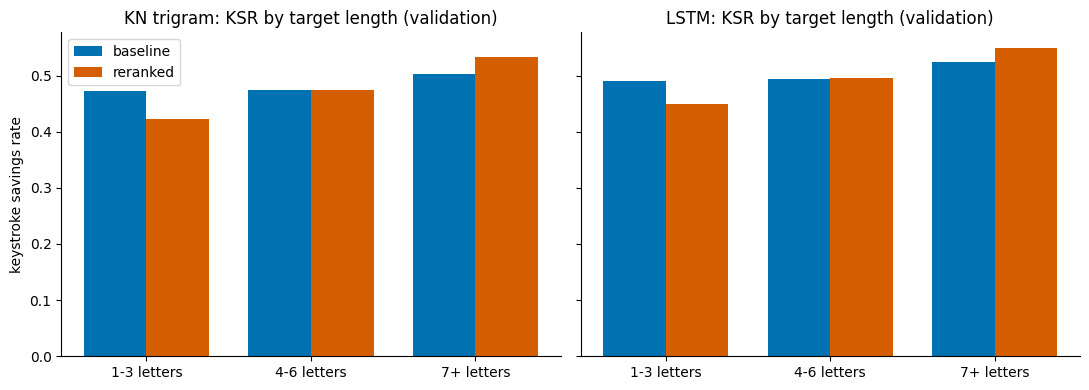

In [3]:
bins = [("1-3", 1, 3), ("4-6", 4, 6), ("7+", 7, 99)]
rows = []
for label in models:
    for mode, name in ((None, "baseline"), ("keystroke", "reranked")):
        d = val_details[(label, mode)]
        length = np.array([len(vocab.itos[t]) for t in d["target"]])
        for bn, lo, hi in bins:
            m = (length >= lo) & (length <= hi)
            rows.append({"model": label, "ordering": name, "target length": bn, "n": int(m.sum()),
                         "top1": float((d["rank"][m] == 1).mean()),
                         "ksr": float(1 - d["keys_with"][m].sum() / d["keys_without"][m].sum())})
bylen = pd.DataFrame(rows)
display(bylen.pivot_table(index=["model", "target length"], columns="ordering", values=["ksr", "top1"]).round(4))
save_table(bylen, "rerank_val_by_length.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, label in zip(axes, models):
    g = bylen[bylen["model"] == label]
    x = np.arange(len(bins)); w = 0.38
    for off, (name, color) in zip((-w / 2, w / 2), (("baseline", BLUE), ("reranked", ORANGE))):
        v = g[g["ordering"] == name].set_index("target length").loc[[b[0] for b in bins], "ksr"]
        ax.bar(x + off, v, w, color=color, label=name)
    ax.set_xticks(x); ax.set_xticklabels([f"{b[0]} letters" for b in bins]); ax.set_title(f"{label}: KSR by target length (validation)")
axes[0].set_ylabel("keystroke savings rate"); axes[0].legend()
plt.tight_layout(); save_fig(fig, "rerank_ksr_by_word_length.png"); plt.show()

## 2. Test (only for models whose validation KSR improved; once each)

In [4]:
base_test = {"KN trigram": pd.read_csv(TAB_DIR / "ngram_test_results.csv").set_index("model").loc["kn3"],
             "LSTM": pd.read_csv(TAB_DIR / "rnn_test_results.csv").set_index("run").loc[R.run_name(cfg)]}
rows = []
for label, model in models.items():
    b = base_test[label]
    rows.append({"model": label, "ordering": "by probability (baseline)", **{c: (float(b[c]) if c in b.index else np.nan) for c in COLS}})
    if improves[label]:
        r = E.evaluate(model, "test", vocab, rerank="keystroke", log=True, name=f"{model.name}+rerank", hyper={"rerank": "keystroke"})
        rows.append({"model": label, "ordering": "by expected keystrokes saved", **{c: float(r[c]) for c in COLS}})
    else:
        print(f"{label}: validation KSR did not improve -> not evaluated on test")
test_df = pd.DataFrame(rows)
display(test_df.round(4))
save_table(test_df, "rerank_test_results.csv")

KN trigram: validation KSR did not improve -> not evaluated on test
LSTM: validation KSR did not improve -> not evaluated on test


,model,ordering,top1,top3,top5,mrr,ksr,archaic_top1,archaic_ksr
0,KN trigram,by probability (baseline),0.1261,0.2246,0.2843,0.2074,0.4771,0.0651,0.5091
1,LSTM,by probability (baseline),0.1387,0.2482,0.3118,0.2259,0.4977,0.0985,NaN


saved table  -> tables/rerank_test_results.csv


saved figure -> figures/rerank_comparison_val.png


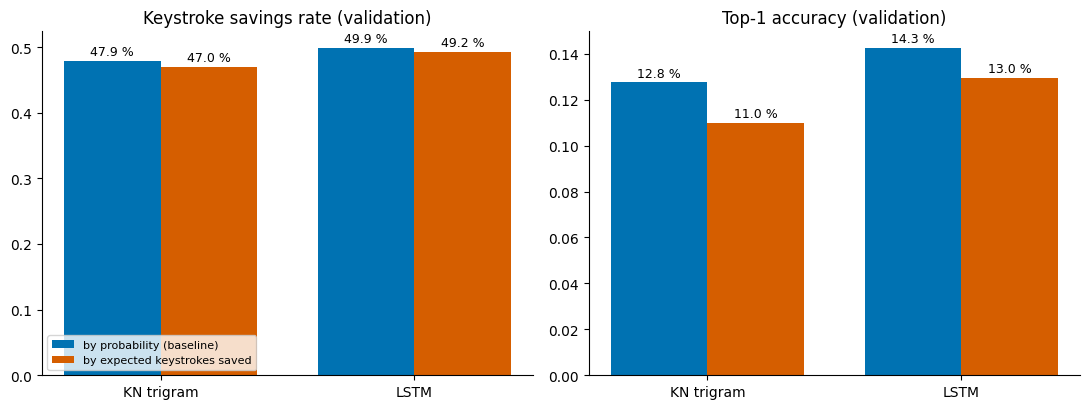

In [5]:
def side_by_side(df, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, (col, ttl) in zip(axes, (("ksr", "Keystroke savings rate"), ("top1", "Top-1 accuracy"))):
        x = np.arange(len(models)); w = 0.38
        for off, (ordering, color) in zip((-w / 2, w / 2), (("by probability (baseline)", BLUE), ("by expected keystrokes saved", ORANGE))):
            v = [float(df[(df["model"] == m) & (df["ordering"] == ordering)][col].iloc[0]) if ((df["model"] == m) & (df["ordering"] == ordering)).any() else np.nan for m in models]
            bars = ax.bar(x + off, v, w, color=color, label=ordering)
            ax.bar_label(bars, labels=["" if np.isnan(t) else f"{100 * t:.1f} %" for t in v], padding=2, fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(list(models)); ax.set_title(f"{ttl} ({title})"); ax.set_ylim(0, None)
    axes[0].legend(fontsize=8)
    plt.tight_layout(); save_fig(fig, fname); plt.show()


side_by_side(val_df, "validation", "rerank_comparison_val.png")
if len(test_df) > len(models):
    side_by_side(test_df, "test", "rerank_comparison_test.png")

## 3. What the keyboard shows (validation prefixes)
For a few prefixes: the three chips by probability vs after reranking (LSTM). The reranked bar trades a little top-1 for longer words.

In [6]:
case_map = D.load_case_map()
val = D.load_split("val", vocab=vocab)
rng = np.random.default_rng(42)
picks = []
for si in rng.choice(len(val), 400, replace=False):
    s = val[si]
    if len(s) >= 9 and len(picks) < 6:
        picks.append((si, 5))
rows = []
for si, i in picks:
    toks = vocab.decode(val[si][1:i])
    text = D.restore_case(toks, case_map) + " "
    for typed in ("", vocab.itos[val[si][i]][:2]):
        t = text + typed
        base = PP.suggest(lstm, vocab, t, case_map, k=3)
        rr = PP.suggest(lstm, vocab, t, case_map, k=3, rerank=True)
        rows.append({"text so far": t, "actual next": vocab.itos[val[si][i]],
                     "chips (probability order)": " | ".join(f"{s_['word']} ({s_['prob']:.2f})" for s_ in base["suggestions"]),
                     "chips (reranked)": " | ".join(f"{s_['word']} ({s_['prob']:.2f})" for s_ in rr["suggestions"])})
ex = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 300)
display(ex)
save_table(ex, "rerank_examples.csv")

,text so far,actual next,chips (probability order),chips (reranked)
0,Nine changes of the,watery,world (0.10) | time (0.04) | night (0.02),world (0.10) | time (0.04) | commonwealth (0.01)
1,Nine changes of the wa,watery,way (0.24) | wars (0.20) | war (0.11),wars (0.20) | way (0.24) | walls (0.06)
2,Plain and not honest,is,men (0.09) | man (0.05) | to (0.03),men (0.09) | gentleman (0.03) | man (0.05)
3,Plain and not honest is,is,is (0.81) | Isabel (0.09) | issue (0.05),Isabel (0.09) | issue (0.05) | Isabella (0.02)
4,"Ah, that thou",wouldst,art (0.15) | hast (0.12) | wert (0.09),hast (0.12) | art (0.15) | wert (0.09)
5,"Ah, that thou wo",wouldst,wouldst (0.84) | would (0.06) | wo't (0.03),wouldst (0.84) | would (0.06) | worthiest (0.02)
6,"Rivers and Hastings,",take,and (0.06) | the (0.02) | to (0.02),and (0.06) | that (0.02) | whose (0.01)
7,"Rivers and Hastings, ta",take,take (0.51) | tam (0.10) | Tamora (0.07),take (0.51) | Tamora (0.07) | Talbot (0.06)
8,My ships are ready,",",to (0.29) | in (0.12) | for (0.07),to (0.29) | in (0.12) | with (0.06)
9,"My ships are ready ,",",",and (0.45) | I (0.04) | sir (0.04),and (0.45) | sir (0.04) | but (0.02)


saved table  -> tables/rerank_examples.csv


## Summary of findings

1. **The reranking does not improve keystroke savings overall.** Validation KSR: KN trigram 47.89 % → 47.01 % (−0.88 points), LSTM 49.90 % → 49.21 % (−0.69 points). By the protocol (test only if validation KSR improves) **neither model was evaluated on test**; the test set was not used for this experiment.
2. **Top-1 drops as expected, and by more than KSR gains could offset:** top-1 12.75 % → 10.99 % (KN) and 14.26 % → 12.95 % (LSTM); top-3 22.8 % → 20.2 % and 25.3 % → 23.9 %; MRR 0.210 → 0.190 and 0.230 → 0.216.
3. **Why it does not pay off:** the rule is myopic and helps only long words. By target length (validation KSR, baseline → reranked): 7+ letters KN 50.3 → 53.3 % (+3.0) and LSTM 52.4 → 55.0 % (+2.6); 4–6 letters unchanged (±0.1); **1–3 letters KN 47.2 → 42.2 % (−5.0), LSTM 49.0 → 44.9 % (−4.1)**. Short words are the most frequent targets, and the simulated keyboard already recovers most of the saving on them by prefix completion after one or two letters, so demoting them costs more than promoting long words gains.
4. **A side effect worth knowing:** on the archaic-keyword targets the reranking helps on validation – top-1 5.9 → 8.8 % (KN) and 8.7 → 12.9 % (LSTM), archaic KSR 50.6 → 52.1 % and 55.5 → 57.3 % – because those words are long and rare. This was not the pre-declared decision criterion and was only measured on validation, so it is a lead for a future experiment, not a result.
5. **The stage stays in the code and the demo as an option** (`suggest(..., rerank=True)`, the "Favour keystroke savings" checkbox in the app), off by default; the main results are unchanged.
6. **Caveats:** one fixed scoring rule was tried (no variants, no tuning, as instructed); validation only; the gain from tapping a word is counted as `len(w) − len(prefix)` keystrokes, exactly the quantity the KSR simulation rewards.